# Klassificering av ansiktsuttryck med neurala nätverk

**Kurs:** Deep Learning
Azar Mohseni

I den här uppgiften ska jag bygga en CNN-modell som kan klassificera
ansiktsuttryck från gråskalebilder

1. Förstå datan
2. Förbered datan
3. Bygg modell
4. Träna modell
5. Utvärdera
6. Prediktioner på ny data
7. Analys
8. Reflektion

## 1. Förstå datan

Först kollar jag hur datan ser ut innan jag börjar bygga modellen.

In [141]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [142]:
train_dir = Path("data/train")
test_dir = Path("data/test")

class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])

print("Antal klasser:", len(class_names))
print("Klasser:", class_names)

Antal klasser: 7
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [143]:
print(f"{'Klass':<12}{'Train':>8}{'Test':>8}")
print("-" * 28)

total_train = 0
total_test = 0

for klass in class_names:
    antal_train = len(list((train_dir / klass).glob("*.jpg")))
    antal_test = len(list((test_dir / klass).glob("*.jpg")))
    total_train += antal_train
    total_test += antal_test
    print(f"{klass:<12}{antal_train:>8}{antal_test:>8}")

print("-" * 28)
print(f"{'Totalt':<12}{total_train:>8}{total_test:>8}")

Klass          Train    Test
----------------------------
angry           3995     958
disgust          436     111
fear            4097    1024
happy           7215    1774
neutral         4965    1233
sad             4830    1247
surprise        3171     831
----------------------------
Totalt         28709    7178


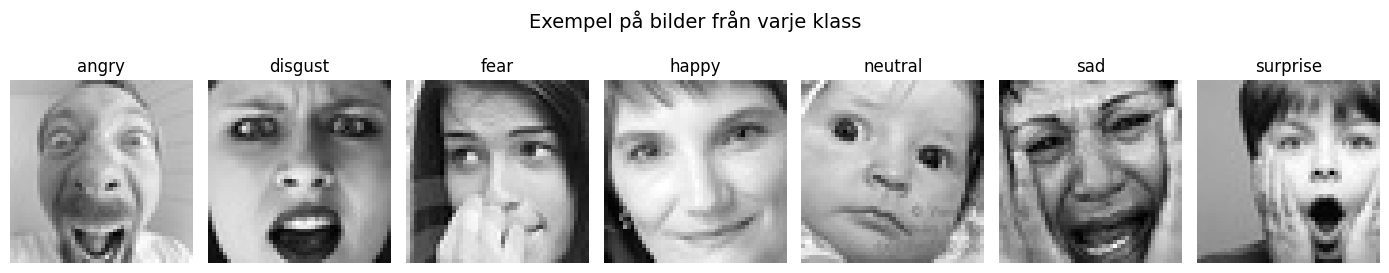

In [144]:
fig, axes = plt.subplots(1, 7, figsize=(14, 3))

for i, klass in enumerate(class_names):
    forsta_bild = next((train_dir / klass).glob("*.jpg"))
    bild = keras.utils.load_img(forsta_bild, color_mode="grayscale")

    axes[i].imshow(bild, cmap="gray")
    axes[i].set_title(klass)
    axes[i].axis("off")

plt.suptitle("Exempel på bilder från varje klass", fontsize=14)
plt.tight_layout()
plt.show()

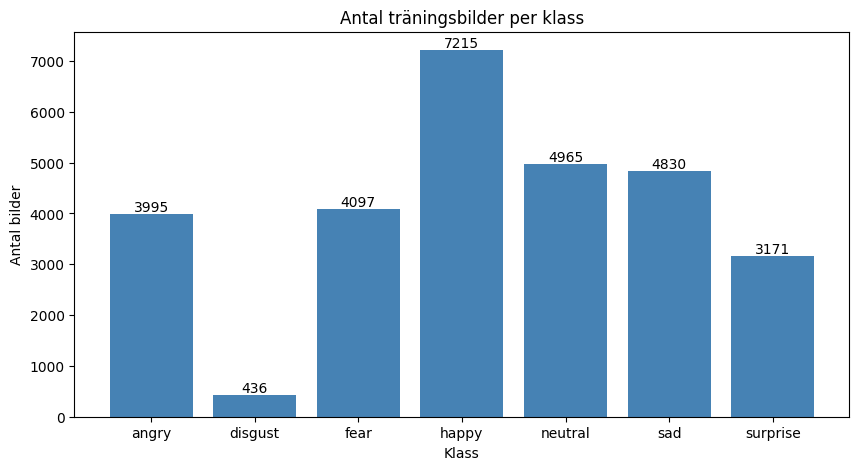

In [145]:
antal_per_klass = []
for klass in class_names:
    antal = len(list((train_dir / klass).glob("*.jpg")))
    antal_per_klass.append(antal)

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, antal_per_klass, color="steelblue")
plt.title("Antal träningsbilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

for bar, antal in zip(bars, antal_per_klass):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             str(antal), ha="center")

plt.show()

### Om datan

Det finns totalt 7 klasser : angry, disgust, fear, happy, neutral, sad och surprise.
Träningsdatan har 28 709 bilder och testdatan 7 178 bilder. Alla bilder är i
gråskala och 48x48 pixlar vilket är ganska lågt.

Datan är inte balanserad. Happy har över 7 000 bilder medan disgust bara har 436.
Det är något jag behöver tänka på senare eftersom modellen troligen kommer ha
svårare att lära sig de klasser som har få bilder.

## 2. Förbered datan

Nu ska jag göra datan klar för modellen. Jag behöver läsa in bilderna,
normalisera pixelvärdena och dela upp träningsdatan i en del för träning
och en del för validering.

Jag använder `image_dataset_from_directory` från Keras eftersom datan redan
ligger sorterad i mappar per klass.

In [146]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

print(f"Bildstorlek: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT}")

Bildstorlek: (48, 48)
Batch size: 64
Validation split: 0.2


In [147]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int"
)


val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [148]:
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [149]:
for images, labels in train_ds.take(1):
    print("Batch-form (bilder):", images.shape)
    print("Batch-form (etiketter):", labels.shape)
    print("Min pixel-värde:", float(tf.reduce_min(images)))
    print("Max pixel-värde:", float(tf.reduce_max(images)))
    print("Exempel-etiketter:", labels[:10].numpy())
    print("Motsvarar klasser:", [class_names[i] for i in labels[:10].numpy()])

Batch-form (bilder): (64, 48, 48, 1)
Batch-form (etiketter): (64,)
Min pixel-värde: 0.0
Max pixel-värde: 1.0
Exempel-etiketter: [2 0 2 6 3 3 6 3 5 3]
Motsvarar klasser: ['fear', 'angry', 'fear', 'surprise', 'happy', 'happy', 'surprise', 'happy', 'sad', 'happy']


W0000 00:00:1780241403.502812 1049088 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. Bygg modellen

Jag bygger en CNN-modell. Den har tre Conv2D-lager med 32, 64 och 128 filter,
varje följt av MaxPooling som halverar storleken. Sen kommer Flatten som gör
om till en 1D-vektor och två Dense-lager där det sista har 7 neuroner — en
per klass.

Jag använder ReLU som aktivering i alla lager utom det sista, där jag har
softmax så jag får ut sannolikheter för varje klass.

In [150]:
NUM_CLASSES = len(class_names)

model = keras.Sequential([
    keras.layers.Input(shape=(48, 48, 1)),

    keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [151]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 4. Träna modellen

Jag tränar i max 20 epochs. För att slippa sitta och vänta i onödan
använder jag EarlyStopping som stoppar träningen om validation loss
inte blivit bättre på 5 epochs i rad. Jag använder också ModelCheckpoint
för att spara den bästa versionen av modellen.

In [152]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, checkpoint]



EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2873 - loss: 1.7663
Epoch 1: val_accuracy improved from None to 0.41038, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.3273 - loss: 1.6915 - val_accuracy: 0.4104 - val_loss: 1.5353
Epoch 2/20
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4248 - loss: 1.5068
Epoch 2: val_accuracy improved from 0.41038 to 0.44835, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.4380 - loss: 1.4653 - val_accuracy: 0.4484 - val_loss: 1.4325
Epoch 3/20
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4846 - loss: 1.3593
Epoch 3: val_accuracy improved from 0.44835 to 0.47936, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.4965 - loss: 1.3298 - va

## 5. Utvärdera modellen

Här ritar jag träningskurvor för accuracy och loss, kör modellen mot testdatan
och tittar på en confusion matrix för att se hur den presterar per klass.

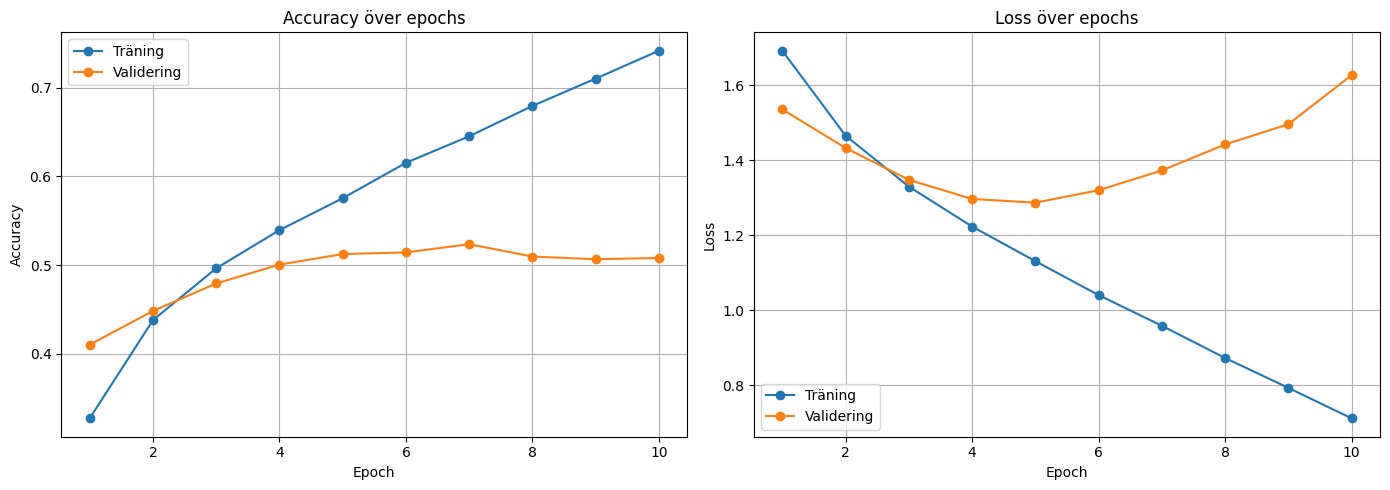

In [153]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc, label="Träning", marker="o")
axes[0].plot(epochs_range, val_acc, label="Validering", marker="o")
axes[0].set_title("Accuracy över epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, loss, label="Träning", marker="o")
axes[1].plot(epochs_range, val_loss, label="Validering", marker="o")
axes[1].set_title("Loss över epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [154]:
bästa_modellen = keras.models.load_model("best_model.keras")

test_loss, test_accuracy = bästa_modellen.evaluate(test_ds, verbose=1)

print(f"Test accuracy: {test_accuracy*100:.1f}%")
print(f"Test loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5280 - loss: 1.3455
Test accuracy: 52.8%
Test loss: 1.3455


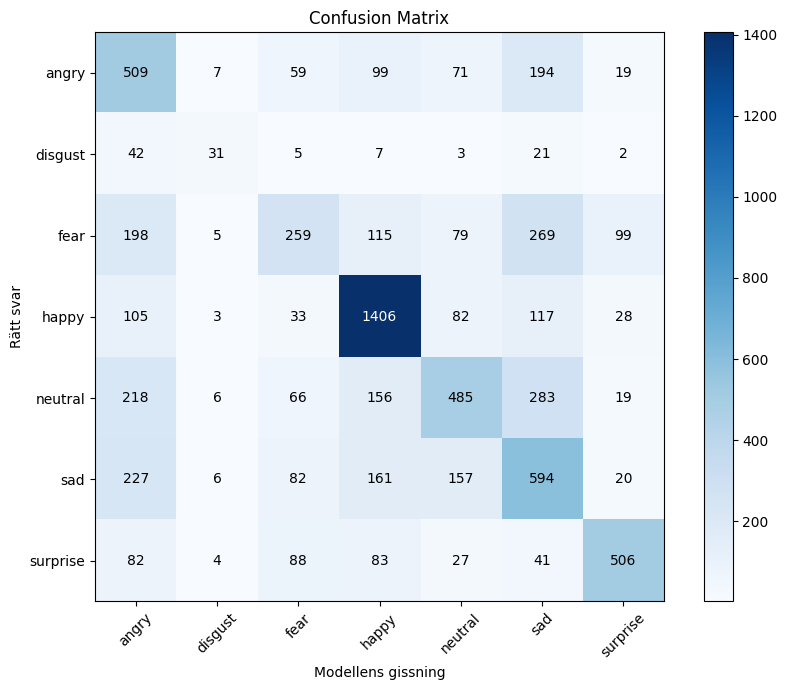

In [155]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for bilder, labels in test_ds:
    predictions = bästa_modellen.predict(bilder, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
ax.set_xlabel("Modellens gissning")
ax.set_ylabel("Rätt svar")
ax.set_title("Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=text_color)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [156]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

       angry       0.37      0.53      0.44       958
     disgust       0.50      0.28      0.36       111
        fear       0.44      0.25      0.32      1024
       happy       0.69      0.79      0.74      1774
     neutral       0.54      0.39      0.45      1233
         sad       0.39      0.48      0.43      1247
    surprise       0.73      0.61      0.66       831

    accuracy                           0.53      7178
   macro avg       0.52      0.48      0.49      7178
weighted avg       0.54      0.53      0.52      7178



## 6. Prediktion på ny data

Nu testar jag modellen på bilder från testdatan för att se vad den
faktiskt gissar. Eftersom testbilderna inte var med i träningen kan jag
se hur modellen presterar på ny data.

In [157]:
def prediktera_bild(bild_sökväg, modell, klassnamn):
    bild = keras.utils.load_img(
        bild_sökväg,
        color_mode="grayscale",
        target_size=(48, 48)
    )

    bild_array = keras.utils.img_to_array(bild)
    bild_array = bild_array / 255.0
    bild_array = np.expand_dims(bild_array, axis=0)

    förutsägelse = modell.predict(bild_array, verbose=0)

    klass_index = np.argmax(förutsägelse[0])
    klass_namn = klassnamn[klass_index]
    säkerhet = förutsägelse[0][klass_index]

    return bild, klass_namn, säkerhet, förutsägelse[0]

In [158]:
test_klass = "happy"
test_bild_sökväg = next((test_dir / test_klass).glob("*.jpg"))

print(f"Testar med bild från klassen: {test_klass}")
print(f"Filsökväg: {test_bild_sökväg}")

bild, predikterad_klass, säkerhet, alla_sannolikheter = prediktera_bild(
    test_bild_sökväg, bästa_modellen, class_names
)

print(f"Modellens gissning: {predikterad_klass}")
print(f"Rätt svar: {test_klass}")
print(f"Säkerhet: {säkerhet*100:.2f}%")

if predikterad_klass == test_klass:
    print("Rätt!")
else:
    print("Fel.")

Testar med bild från klassen: happy
Filsökväg: data/test/happy/PrivateTest_45699463.jpg
Modellens gissning: happy
Rätt svar: happy
Säkerhet: 99.98%
Rätt!


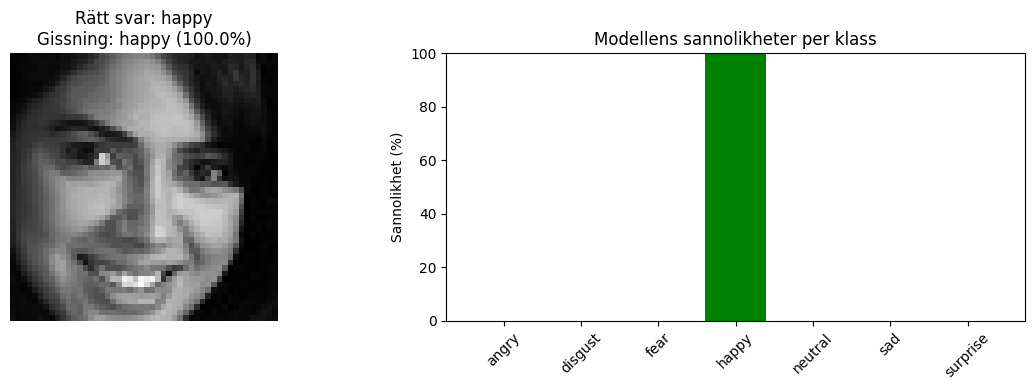

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(bild, cmap="gray")
axes[0].set_title(f"Rätt svar: {test_klass}\nGissning: {predikterad_klass} ({säkerhet*100:.1f}%)")
axes[0].axis("off")

färger = ["green" if c == predikterad_klass else "steelblue" for c in class_names]
axes[1].bar(class_names, alla_sannolikheter * 100, color=färger)
axes[1].set_title("Modellens sannolikheter per klass")
axes[1].set_ylabel("Sannolikhet (%)")
axes[1].set_ylim(0, 100)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

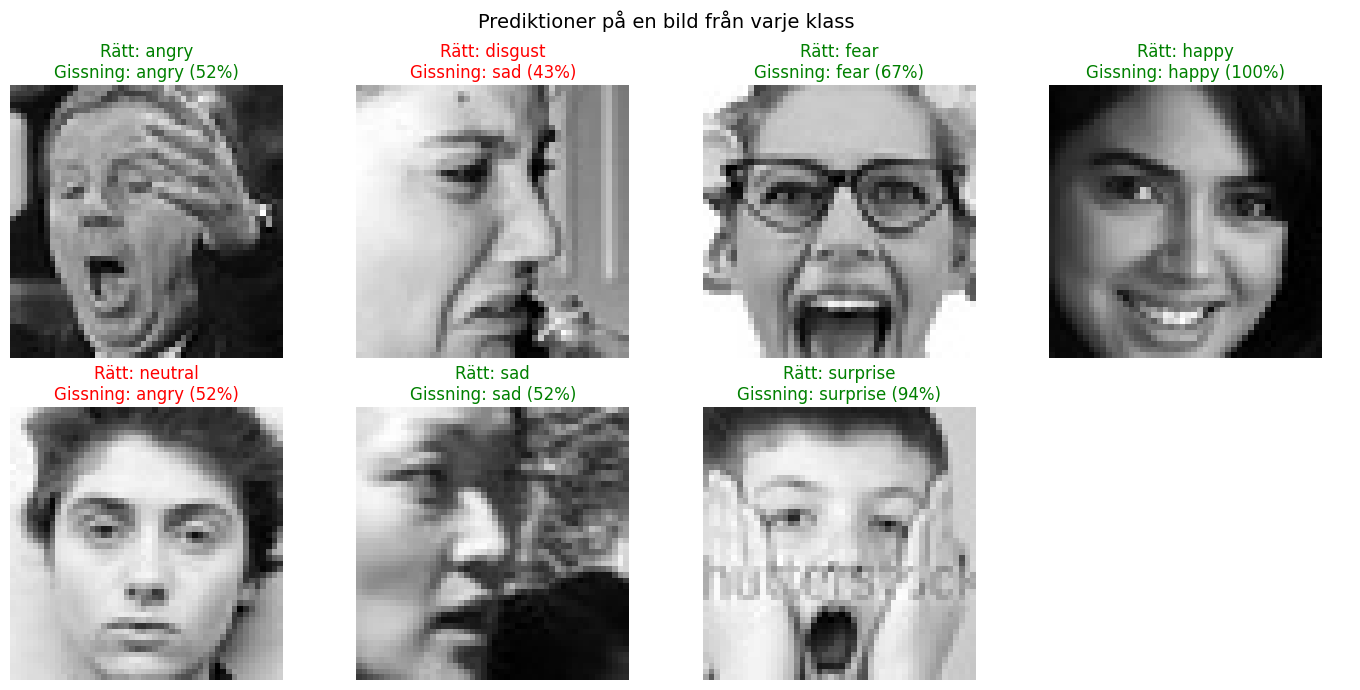

In [160]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, klass in enumerate(class_names):
    bild_sökväg = next((test_dir / klass).glob("*.jpg"))
    bild, predikterad_klass, säkerhet, _ = prediktera_bild(
        bild_sökväg, bästa_modellen, class_names
    )

    rätt = predikterad_klass == klass
    färg = "green" if rätt else "red"

    axes[i].imshow(bild, cmap="gray")
    axes[i].set_title(
        f"Rätt: {klass}\nGissning: {predikterad_klass} ({säkerhet*100:.0f}%)",
        color=färg
    )
    axes[i].axis("off")

axes[7].axis("off")

plt.suptitle("Prediktioner på en bild från varje klass", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Analys av resultatet

Modellen får 52% rätt på testdatan. Det är inte jättebra men ändå mycket
bättre än att gissa slumpmässigt (då hade jag fått runt 14% eftersom det
finns 7 klasser). Människor brukar få ungefär 65% rätt på samma dataset
så det finns en hel del kvar att förbättra.

Resultatet skiljer sig mycket mellan klasserna. Happy klassificeras bäst
med F1-score 0.73 och surprise näst bäst på 0.66. Sämst går det för fear
och disgust som bara ligger runt 0.34-0.38. Det är inte så förvånande
tycker jag - disgust har bara 436 träningsbilder vilket är väldigt få,
och uttryck som sad, neutral och fear ser ganska lika ut när bilderna
bara är 48x48 pixlar.

När jag jämför träningsdata och testdata syns overfitting tydligt.
Träningsaccuracy slutade på runt 73% medan både validering och test bara
nådde 52-53%. Det är ett gap på cirka 20 procentenheter. Det betyder att
modellen lärt sig träningsbilderna utantill istället för att hitta
generella mönster.

Det som verkar påverka resultatet mest är klassobalansen och att bilderna
är så låg upplösta. Min modell är också ganska enkel - den saknar saker
som dropout och annat som hade hjälpt mot overfitting. Andra begränsningar
är att modellen bara är tränad på FER-2013 så den skulle troligen prestera
sämre på andra typer av ansiktsbilder, och att den inte kan hantera bra
om ansiktet är vänt i en konstig vinkel eller är dåligt belyst.

## 8. Reflektion

### Vad var svårast?

Det svåraste var nog att förstå hur ett CNN egentligen fungerar i början.
Varför man behöver Conv2D, varför MaxPooling halverar bilden, och hur
Flatten passar in. Jag fick googla en del och titta på mina egna
träningskurvor innan det började klicka.

### Vad lärde jag mig?

Jag lärde mig hur man bygger en CNN-modell i Keras, hur man förbereder
bilddata och hur viktigt det är att ha en separat valideringsuppsättning
under träningen. Det jag tycker var mest värdefullt var att se overfitting
hända i mina egna kurvor - innan har jag bara läst om det. Nu förstår jag
varför man behöver tekniker för att hantera det.

Jag lärde mig också att accuracy inte räcker som mått när datan är
obalanserad. Confusion matrix gav mycket bättre bild av vad modellen
faktiskt klarar.